<a href="https://colab.research.google.com/github/doney25/CaseStudy/blob/main/CaseStudy_Unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
df=pd.read_csv('/content/adult_dataset.csv')
df.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [104]:
df.shape

(48842, 15)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


##Data Preprocessing

In [106]:
df.replace('?', np.nan, inplace=True)

In [107]:
df.isna().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


####Missing Value Handling

In [108]:
df.duplicated().sum()

np.int64(16)

In [109]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True,inplace=True)
df.shape

(48826, 15)

In [110]:
df['age']=df['age'].fillna(df['age'].mean())
df['hours-per-week']=df['hours-per-week'].fillna(df['hours-per-week'].mean())

In [111]:
df['workclass']=df['workclass'].fillna(df['workclass'].mode()[0])
df['occupation']=df['occupation'].fillna(df['occupation'].mode()[0])
df['native-country']=df['native-country'].fillna(df['native-country'].mode()[0])

In [112]:
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [113]:
num_cols = df.select_dtypes(include=np.number).columns

In [114]:
cat_cols=df.select_dtypes(include='object').columns

In [115]:
num_cols

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

####Outlier Removal

In [116]:
num_cols = num_cols.drop(['capital-gain', 'capital-loss'])

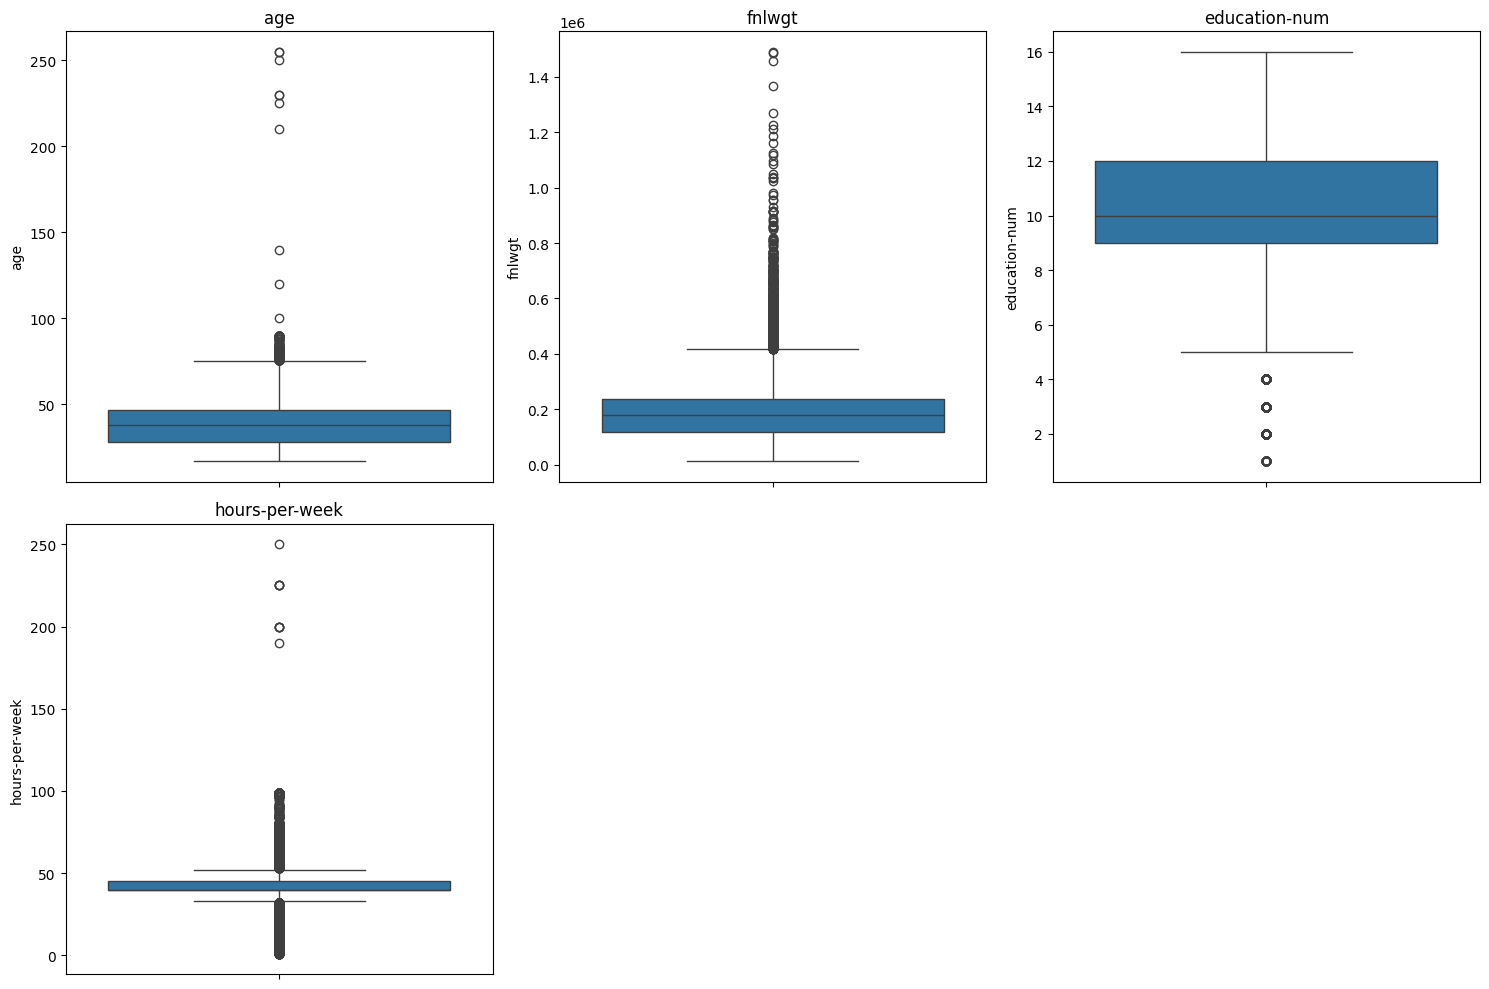

In [117]:
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols,1):
  plt.subplot(2,3,i)
  sns.boxplot(y=df[col])
  plt.title(col)

plt.tight_layout()
plt.show()

In [118]:
for i in num_cols:
  Q1=df[i].quantile(0.25)
  Q3=df[i].quantile(0.75)
  IQR=Q3-Q1

  lower_bound=Q1-1.5*IQR
  upper_bound=Q1+1.5*IQR

  df[i]=np.where(df[i]<lower_bound,lower_bound,df[i])
  df[i]=np.where(df[i]>upper_bound,upper_bound,df[i])

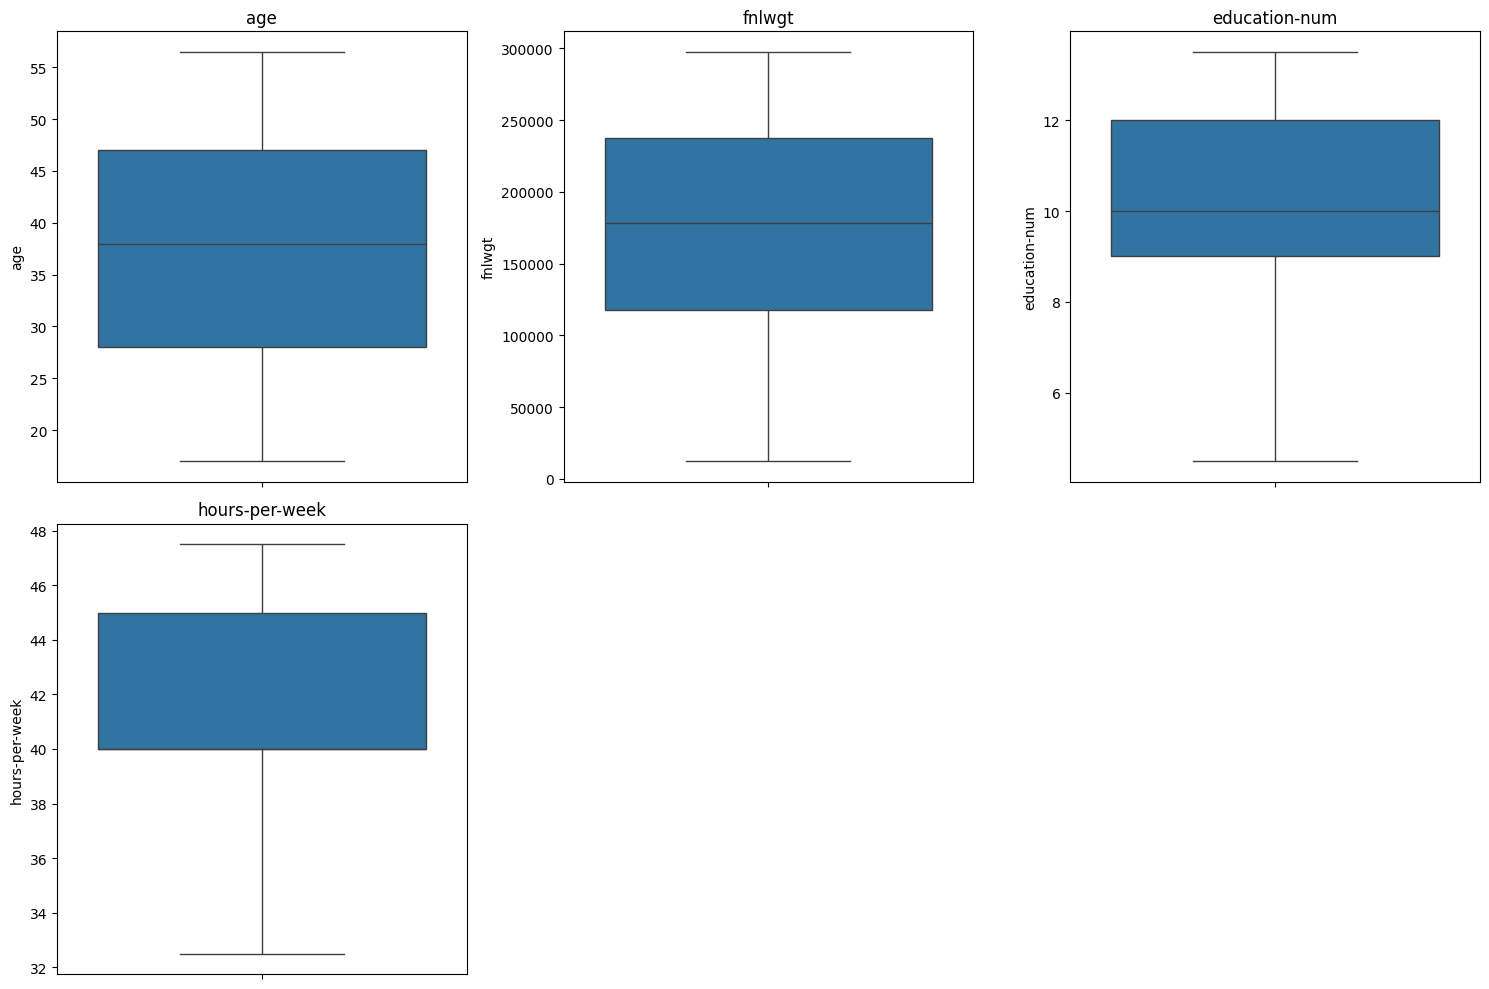

In [119]:
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols,1):
  plt.subplot(2,3,i)
  sns.boxplot(y=df[col])
  plt.title(col)

plt.tight_layout()
plt.show()

####Encoding

In [120]:
cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

In [121]:
original_df = df.copy()

In [122]:
income=df['income']
df.drop('income', axis=1, inplace=True)

In [123]:
cat_cols = df.select_dtypes(include='object').columns

In [124]:
X_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)
display(X_encoded.head())

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39.0,77516.0,13.0,2174,0,40.0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50.0,83311.0,13.0,0,0,32.5,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,38.0,215646.0,9.0,0,0,40.0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,53.0,234721.0,7.0,0,0,40.0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
4,28.0,297648.0,13.0,0,0,40.0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


####Scaling

In [125]:
from sklearn.preprocessing import StandardScaler

In [126]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(X_encoded)

In [127]:
scaled_data = pd.DataFrame(scaled_data,columns=X_encoded.columns,index=X_encoded.index)
display(scaled_data.head())

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,0.101105,-1.270573,1.281529,0.146861,-0.217164,-0.085387,-0.254632,-0.013578,-1.802003,-0.185487,...,-0.036791,-0.059975,-0.020243,-0.046644,-0.035368,-0.024378,-0.022634,0.296968,-0.041265,-0.021709
1,1.039684,-1.197230,1.281529,-0.144828,-0.217164,-1.640480,-0.254632,-0.013578,-1.802003,-0.185487,...,-0.036791,-0.059975,-0.020243,-0.046644,-0.035368,-0.024378,-0.022634,0.296968,-0.041265,-0.021709
2,0.015780,0.477638,-0.449662,-0.144828,-0.217164,-0.085387,-0.254632,-0.013578,0.554938,-0.185487,...,-0.036791,-0.059975,-0.020243,-0.046644,-0.035368,-0.024378,-0.022634,0.296968,-0.041265,-0.021709
3,1.295660,0.719057,-1.315257,-0.144828,-0.217164,-0.085387,-0.254632,-0.013578,0.554938,-0.185487,...,-0.036791,-0.059975,-0.020243,-0.046644,-0.035368,-0.024378,-0.022634,0.296968,-0.041265,-0.021709
4,-0.837474,1.515479,1.281529,-0.144828,-0.217164,-0.085387,-0.254632,-0.013578,0.554938,-0.185487,...,-0.036791,-0.059975,-0.020243,-0.046644,-0.035368,-0.024378,-0.022634,-3.367365,-0.041265,-0.021709


##EDA

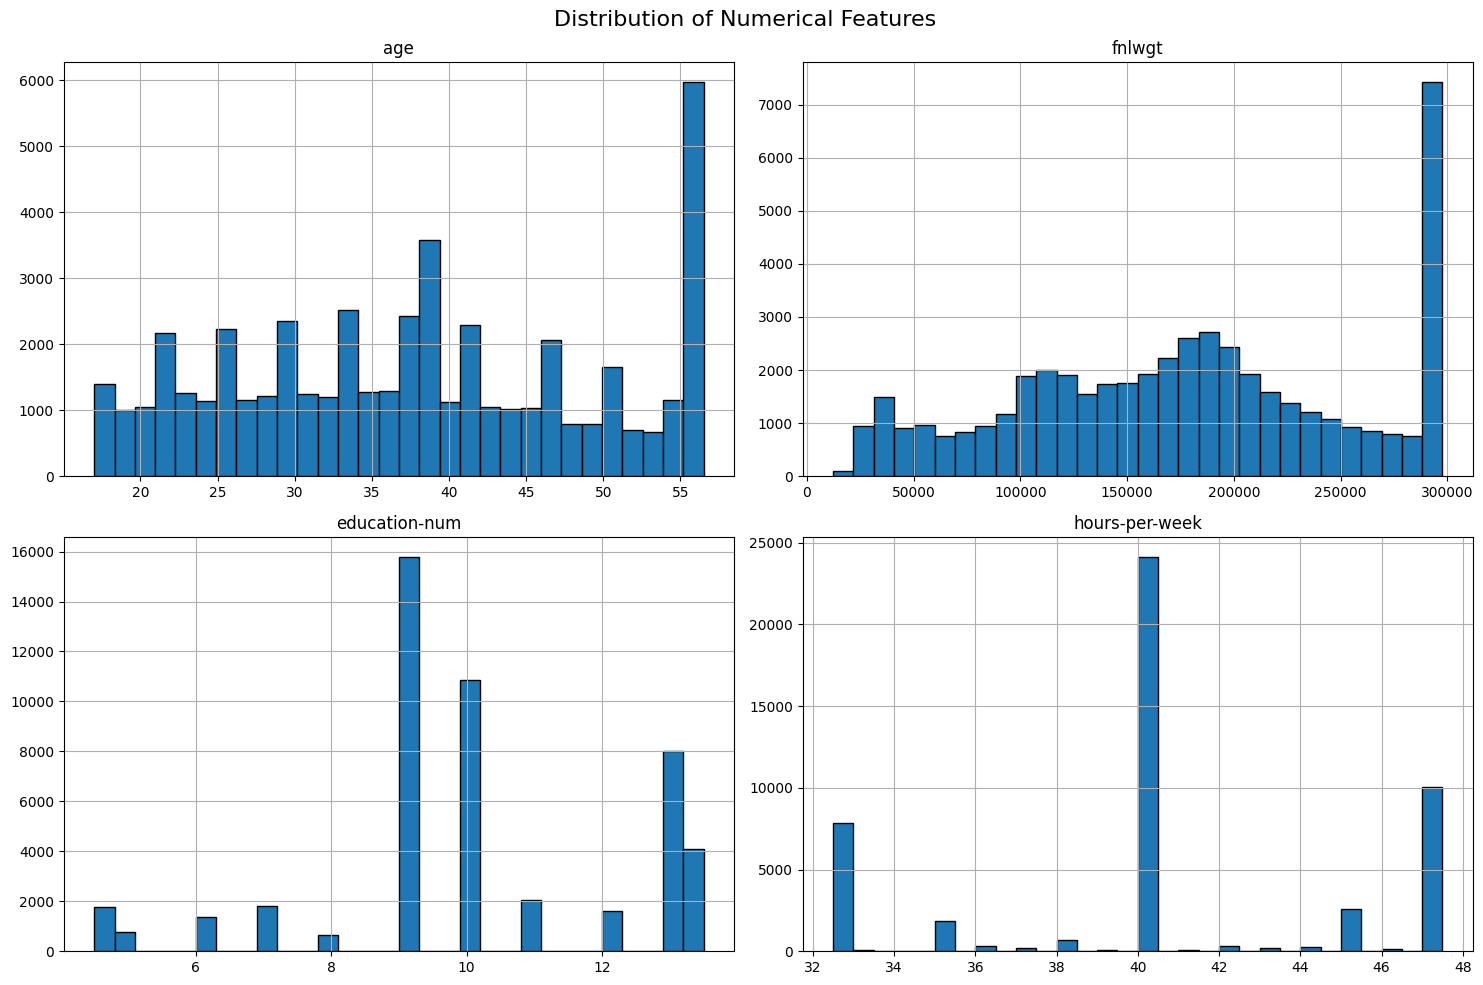

In [128]:
df[num_cols].hist(
    figsize=(15, 10),
    bins=30,
    edgecolor='black')

plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

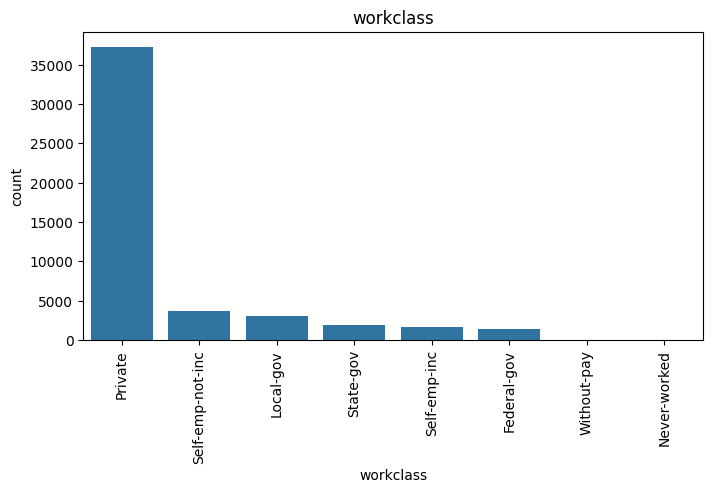

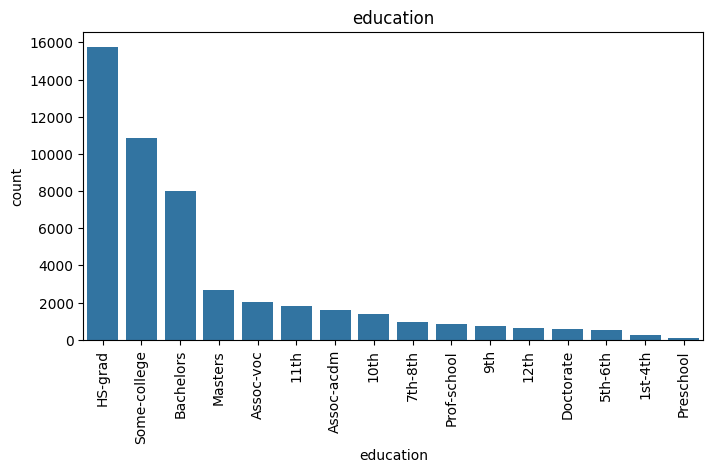

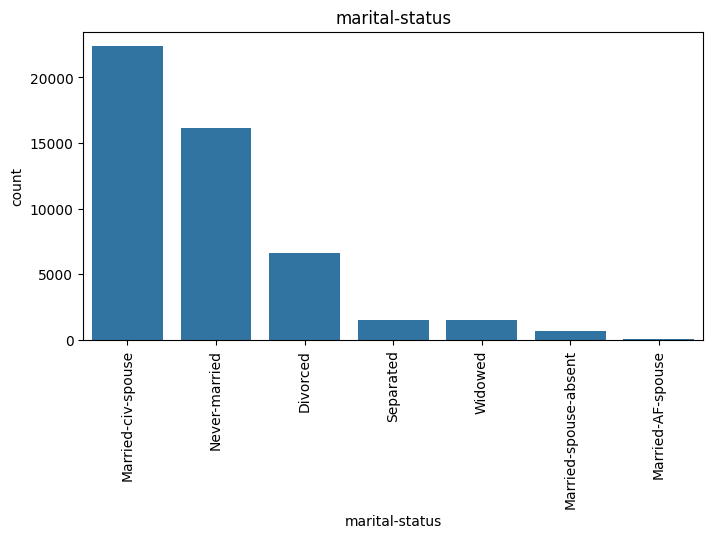

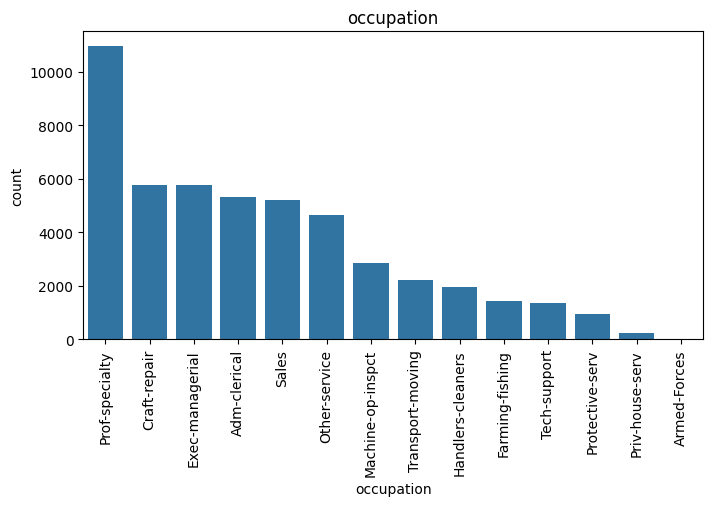

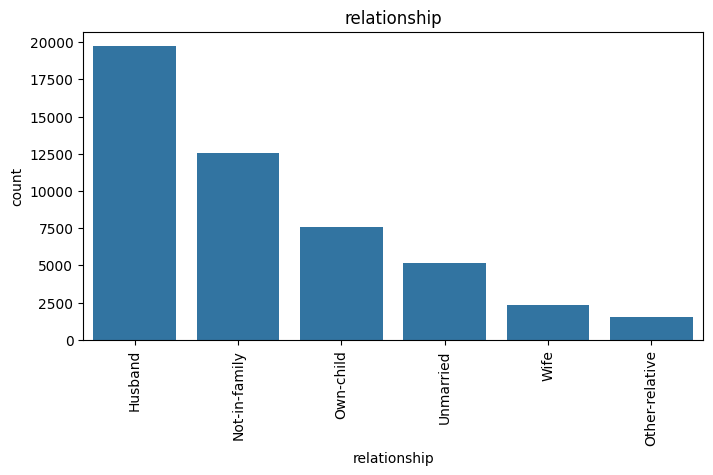

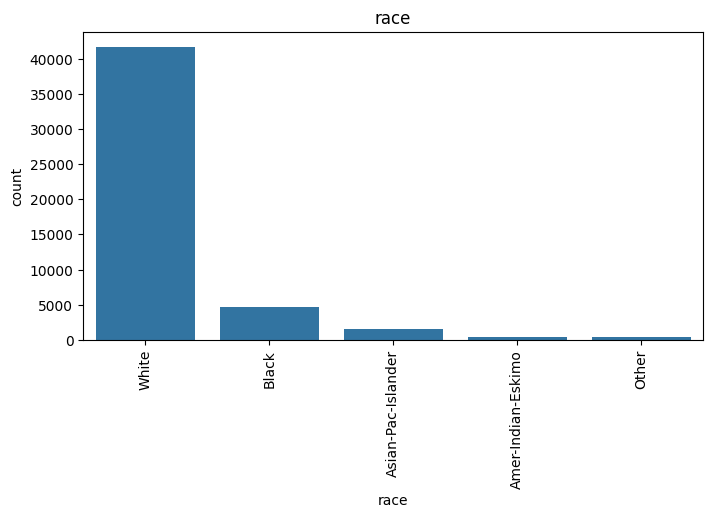

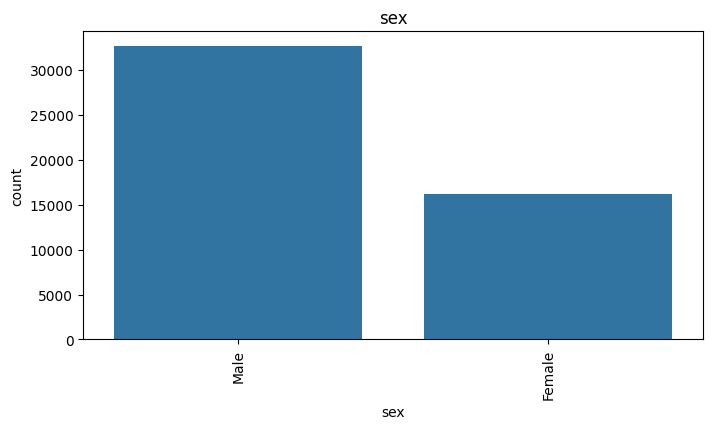

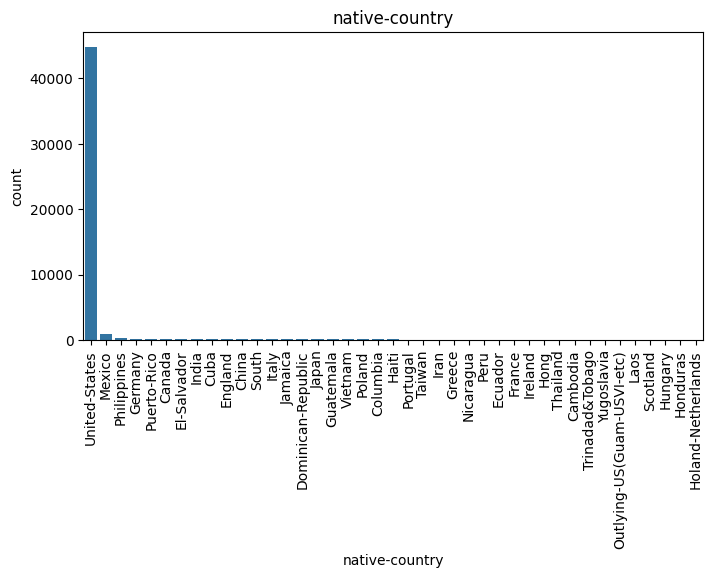

In [129]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df,
                  x=col,
                  order=df[col].value_counts().index)
    plt.xticks(rotation=90)
    plt.title(col)
    plt.show()

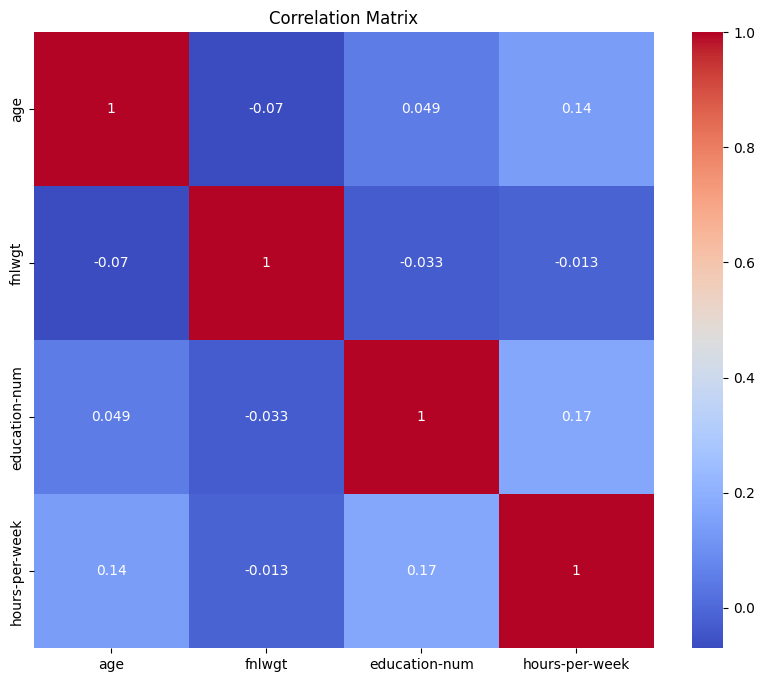

In [130]:
plt.figure(figsize=(10,8))

sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

In [131]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(scaled_data)

In [132]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2'],
    index=scaled_data.index
)

pca_df.head()

,PC1,PC2
0,0.857184,2.661489
1,3.202051,0.658491
2,-0.824986,-0.500151
3,-1.083681,-2.126330
4,0.114081,-0.994172


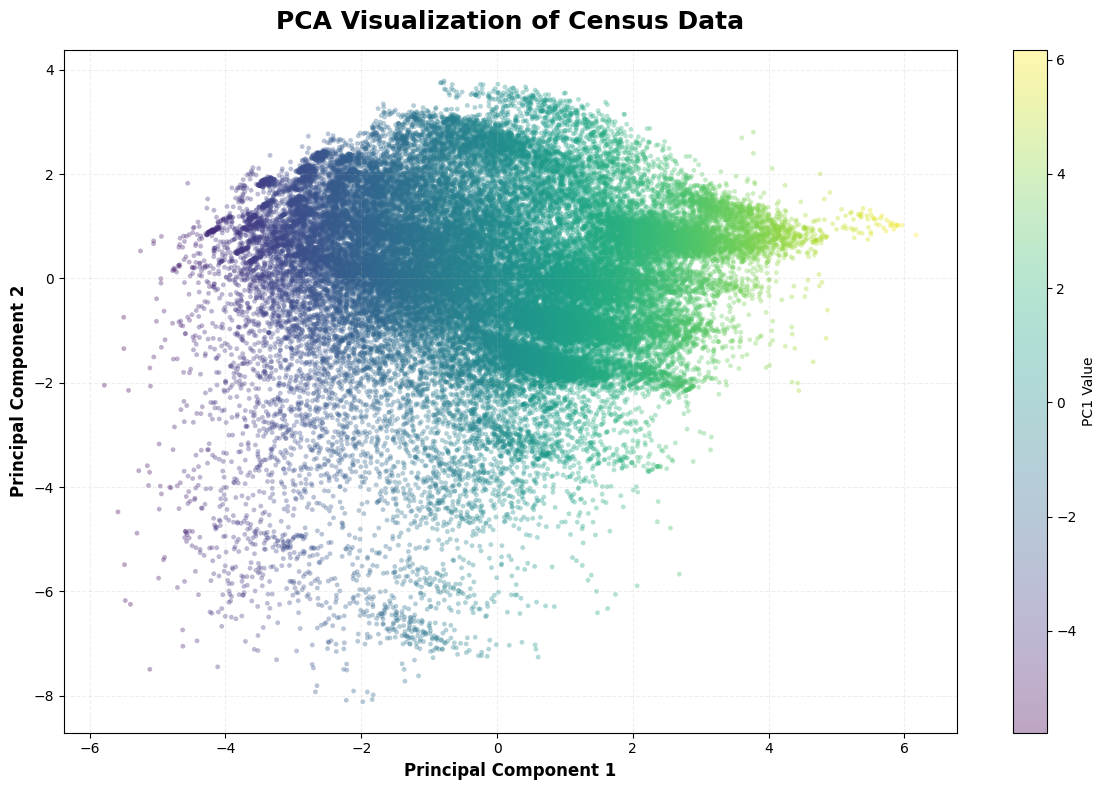

In [133]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['PC1'],
    cmap='viridis',
    s=12,
    alpha=0.35,
    edgecolors='none'
)

plt.colorbar(
    scatter,
    label='PC1 Value'
)

plt.title(
    'PCA Visualization of Census Data',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Principal Component 1',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Principal Component 2',
    fontsize=12,
    fontweight='bold')

plt.grid(alpha=0.2,linestyle='--')

plt.tight_layout()
plt.show()

##Clustering

In [134]:
from sklearn.cluster import KMeans

wcss_list = []
for i in range(1,11) :
  kmeans = KMeans(n_clusters = i,init = 'k-means++',random_state = 42)
  kmeans.fit(scaled_data)
  wcss_list.append(kmeans.inertia_)
wcss_list

[4736122.000000006,
 4686559.692464177,
 4557322.966449483,
 4496469.968061768,
 4484141.0628305115,
 4397781.525639337,
 4332989.356370467,
 4311877.02489351,
 4248617.279219756,
 4198971.759161187]

Text(0, 0.5, 'WCSS')

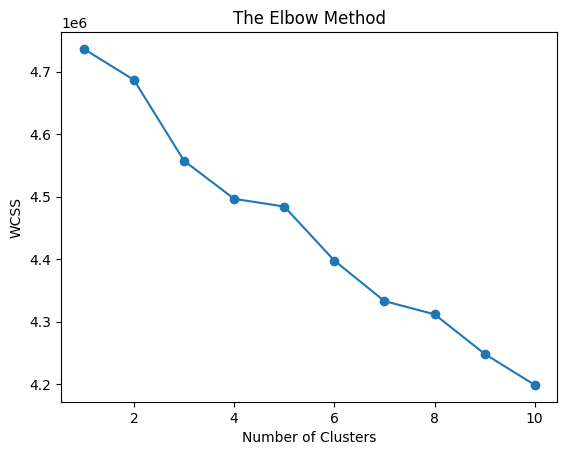

In [135]:
plt.plot(range(1,11),wcss_list,marker = 'o')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

##Silhoutte Score

In [136]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(
        scaled_data,
        labels,
        sample_size=10000,
        random_state=42
    )

    silhouette_scores.append(score)

    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.0510
K = 3: Silhouette Score = 0.0541
K = 4: Silhouette Score = 0.0414
K = 5: Silhouette Score = 0.0362
K = 6: Silhouette Score = 0.0439
K = 7: Silhouette Score = 0.0182
K = 8: Silhouette Score = 0.0397
K = 9: Silhouette Score = 0.0421
K = 10: Silhouette Score = 0.0561


In [137]:
final_kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)
kmeans_labels = final_kmeans.fit_predict(scaled_data)
df['KMeans_Cluster'] = kmeans_labels
print(df['KMeans_Cluster'].value_counts().sort_index())

KMeans_Cluster
0    11777
1       19
2    19271
3    16385
4     1374
Name: count, dtype: int64


In [138]:
df['KMeans_Cluster'].value_counts()

,count
KMeans_Cluster,
2,19271
3,16385
0,11777
4,1374
1,19


In [139]:
pca_df['KMeans_Cluster'] = kmeans_labels

In [147]:
original_df['Cluster'] = kmeans_labels

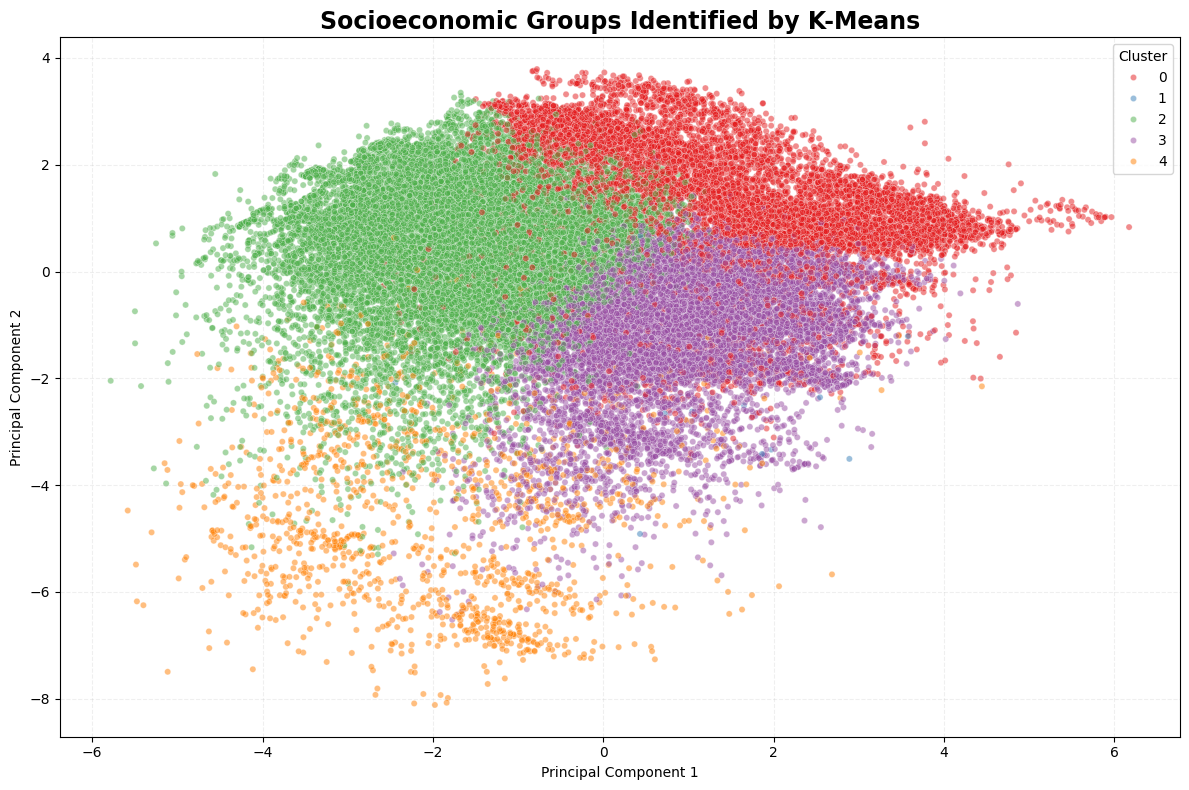

In [140]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='KMeans_Cluster',
    palette='Set1',
    alpha=0.5,
    s=20
)

plt.title(
    'Socioeconomic Groups Identified by K-Means',
    fontsize=17,
    fontweight='bold'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.legend(
    title='Cluster',
    loc='best'
)

plt.grid(alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

##Agglomerative Clustering

In [141]:
sample_size = 10000

sample_data =scaled_data.sample(n=sample_size,random_state=42)

print("Sample shape:", sample_data.shape)

Sample shape: (10000, 97)


In [142]:
from sklearn.cluster import AgglomerativeClustering

agg_model = AgglomerativeClustering(n_clusters=5,linkage='ward')

agg_labels = agg_model.fit_predict(sample_data)

print("Agglomerative Clustering completed.")

Agglomerative Clustering completed.


In [143]:
print(pd.Series(agg_labels).value_counts().sort_index())

0     771
1    4818
2      27
3    4379
4       5
Name: count, dtype: int64


In [144]:
agg_score = silhouette_score(
    sample_data,
    agg_labels,
    sample_size=5000,
    random_state=42
)

print(
    "Agglomerative Silhouette Score:",
    round(agg_score, 4)
)

Agglomerative Silhouette Score: 0.0197


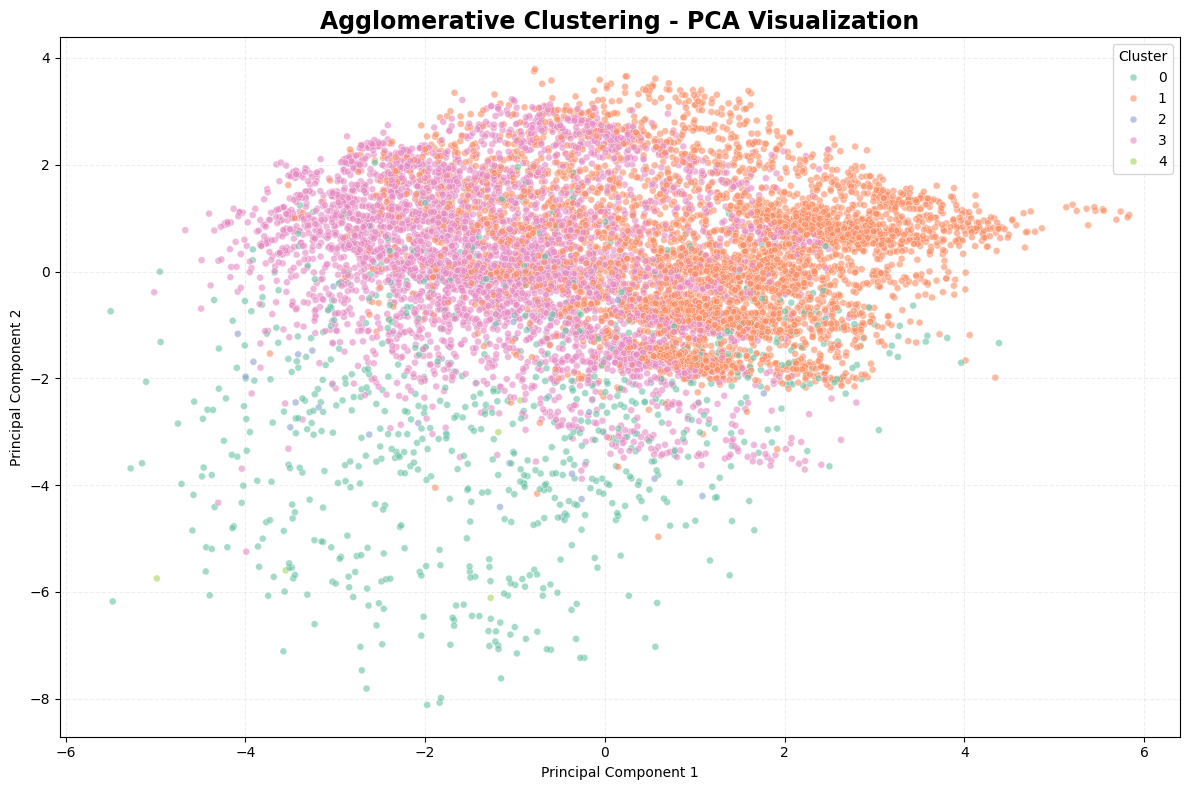

In [145]:
agg_pca = pca_df.loc[
    sample_data.index,
    ['PC1', 'PC2']
].copy()

agg_pca['Agg_Cluster'] = agg_labels

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=agg_pca,
    x='PC1',
    y='PC2',
    hue='Agg_Cluster',
    palette='Set2',
    alpha=0.6,
    s=25
)

plt.title(
    'Agglomerative Clustering - PCA Visualization',
    fontsize=17,
    fontweight='bold'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')

plt.grid(alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

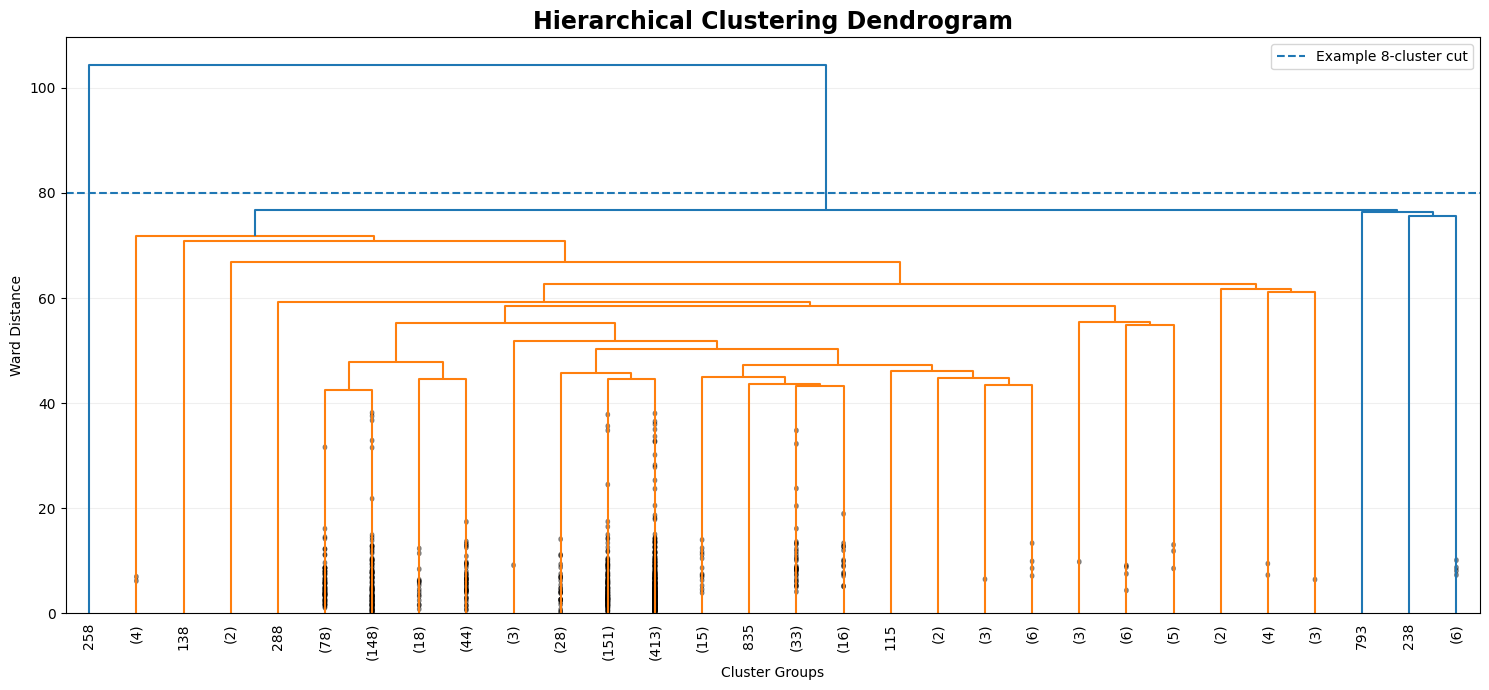

In [146]:
from scipy.cluster.hierarchy import dendrogram, linkage

X_dendro = scaled_data.sample(
    n=1000,
    random_state=42
)

linked = linkage(X_dendro, method='ward')

plt.figure(figsize=(15, 7))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.axhline(
    y=80,
    linestyle='--',
    label='Example 8-cluster cut'
)

plt.title(
    'Hierarchical Clustering Dendrogram',
    fontsize=17,
    fontweight='bold'
)

plt.xlabel('Cluster Groups')
plt.ylabel('Ward Distance')
plt.legend()
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

##Profiling

In [148]:
num_cols = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]

cluster_profile = original_df.groupby('Cluster')[num_cols].mean().round(2)

cluster_profile

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
Cluster,,,,,,
0,40.50,175023.08,13.15,2910.08,152.35,41.99
1,46.47,187411.05,10.89,490.32,87.79,40.44
2,32.57,179981.27,9.22,217.79,44.59,38.55
3,42.18,173224.68,9.07,830.78,95.86,41.53
4,36.08,229230.01,6.45,446.13,34.92,39.67


In [150]:
original_df['income'] = original_df['income'].replace({
    '<=50K.': '<=50K',
    '>50K.': '>50K'
})

In [151]:
pd.crosstab(
    original_df['Cluster'],
    original_df['income'],
    normalize='index'
).round(2) * 100

income,<=50K,>50K
Cluster,,
0,50.0,50.0
1,68.0,32.0
2,98.0,2.0
3,68.0,32.0
4,95.0,5.0


#####  **Cluster 0 – Highly Skilled Professionals**

  * Average age: 40.5 years<br>
  * Highest education level <br>
* Highest capital gain <br>
* Highest working hours <br>
* 50% earn more than $50K (highest among all clusters)

##### **Cluster 1 – Experienced Working Adults**

* Oldest average age (46.47)
* Moderate education
* Moderate capital gain
* Standard working hours
* 32% earn >50K

##### **Cluster 2 – Young Low-Income Workforce**

* Youngest average age (32.57)
* Low education
* Lowest capital gain
* Lowest working hours
* 98% earn <=50K
##### **Cluster 3 – Stable Middle-Class Workers**

* Average age around 42
* Moderate education
* Moderate capital gain
* Standard working hours
* 32% earn >50K

##### **Cluster 4 – Educationally Disadvantaged Group**

* Lowest education (6.45)
* Relatively young
* Low capital gain
* Majority lower-income
* 95% earn <=50K

#Summary

The clustering analysis identified five distinct socioeconomic groups. Education level, capital gain, age, and working hours emerged as the main characteristics differentiating the clusters. Cluster 0 contained the highest proportion of higher-income individuals and was characterized by the highest education level and capital gains. In contrast, Clusters 2 and 4 were dominated by individuals earning <=50K, reflecting lower education levels and weaker financial indicators. These results suggest that educational attainment and financial assets are strongly associated with socioeconomic status, making them important factors for designing targeted employment, welfare, and financial literacy policies